# Demo · Un asistente clínico con supervisión humana, explicabilidad y control de sesgos

Notebook que acompaña al paper «De la "alucinación" al *bullshit*: supervisión humana explícita, explicabilidad y control de sesgos para LLM en salud» (Mateo Rubio y Diego Polanco · Inteligencia Artificial · Universidad ICESI).

### ¿Qué hace esta demo?

Simula, con datos sintéticos, un asistente clínico basado en IA que produce dos tipos de salida:

1. **Afirmaciones en texto**, como las que escribiría un LLM (por ejemplo, «la dosis de amoxicilina en niños es 25 mg por kg cada 12 horas»).
2. **Puntajes de riesgo** de reingreso hospitalario para 20 000 pacientes ficticios.

Luego hace pasar esas salidas por las tres capas de la arquitectura que propone el paper —calibrar la confianza, verificar contra evidencia y explicar, y decidir cuándo interviene una persona mientras se auditan los sesgos— y mide cada capa con la métrica que el paper propone para ella.

### ¿Por qué?

El paper sostiene que los errores de los LLM son estructurales (el modelo aprende a imitar texto, no a decir la verdad) y que, por eso, la solución no está dentro del modelo sino en la arquitectura que lo rodea. La demo vuelve esa tesis **observable**: muestra que cada componente se puede implementar y medir en pocas líneas, y deja ver con números los límites que el paper discute en su sección 3 (*trade-offs*).

**¿Por qué no usar un LLM real?** Porque las capas de la arquitectura actúan sobre las *salidas* del modelo —una probabilidad, una afirmación, una decisión—, sin importar qué modelo las produjo. Simularlas hace que la demo sea reproducible, gratuita, sin claves de API y que corra en segundos. El costo es que no mide el desempeño clínico de un modelo real; eso no es lo que el paper afirma.

### ¿Cómo se acomoda al paper?

| Acto | Pregunta | Sección del paper | Qué muestra | Afirmación del paper que respalda |
|---|---|---|---|---|
| 1 | ¿Podemos creerle a su confianza? | 2.1 · calibración | Diagrama de fiabilidad antes y después de *temperature scaling* | La confianza debe calibrarse antes de usarse para decidir |
| 2 | ¿Está respaldada por evidencia? | 2.2 · ecuación (2) | La similitud no distingue «25 mg» de «250 mg»; el verificador sí (casi siempre) | La condición de implicación lógica (NLI) es indispensable |
| 2b | ¿Por qué marcó a este paciente? | 2.2 · valores de Shapley | Contribuciones exactas por variable, que delatan un *proxy* | La explicación describe patrones del modelo, no razones clínicas |
| 3 | ¿Cuándo debe decidir una persona? | 2.3 · ecuación (3) | Umbral de escalado derivado de costos y efecto del sesgo de automatización | Si el revisor no detecta errores, la supervisión es nominal |
| 4 | ¿Es justo con ambos grupos? | 2.3 · ecuación (4) y sección 3 | Corregir una brecha entre grupos agranda otra | La equidad no es un escalar |
| 5 | Panel de control | Tabla 1 | Todas las métricas juntas | — |

> ⚠️ **Datos 100 % sintéticos** (semilla fija = 7). La demo reproduce el *mecanismo* y la *forma de medirlo*; no es evidencia clínica ni el desempeño de un LLM real.

## 0 · Datos sintéticos y modelo de riesgo

**Qué hace.** Crea 20 000 pacientes ficticios con cinco variables (edad, comorbilidades, deterioro renal, baja adherencia al tratamiento y zona de residencia) y un atributo sensible $A$ (grupo 0 o grupo 1). La zona de residencia está correlacionada con $A$, como ocurre en la vida real con el barrio o el estrato. Con esos datos entrena un modelo de riesgo de reingreso hospitalario que **no ve** $A$.

**Por qué.** Da un «modelo desplegado» concreto sobre el cual aplicar las capas de la arquitectura en los actos 1, 2b, 3 y 4. Usar datos sintéticos con semilla fija garantiza que cualquiera obtenga exactamente los mismos resultados.

In [1]:
#@title ⚙️ 0 · Configuración y datos sintéticos (ejecutar primero)
import re
from itertools import combinations
from math import factorial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity

rng = np.random.default_rng(7)                      # semilla fija -> resultados reproducibles
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
AZUL, NARANJA, GRIS, VERDE = "#2563eb", "#ea580c", "#9ca3af", "#16a34a"
sigmoid = lambda z: 1 / (1 + np.exp(-z))
PANEL = {}                                          # resultados para el panel final

# --- Pacientes sintéticos: riesgo de reingreso hospitalario -----------------
N = 20000
A = rng.binomial(1, 0.5, N)                         # atributo sensible (grupo 0 / grupo 1)
X = pd.DataFrame({
    "edad":            rng.normal(0, 1, N),         # estandarizada
    "comorbilidades":  rng.normal(0, 1, N),         # índice estandarizado
    "deterioro_renal": rng.binomial(1, 0.30, N),
    "baja_adherencia": rng.binomial(1, 0.35, N),
    "zona_residencia": 0.9 * A + rng.normal(0, 1, N),   # PROXY correlacionado con A
})
logit_real = (-2.0 + 1.6 * X.edad + 1.4 * X.comorbilidades + 2.0 * X.deterioro_renal
              + 1.5 * X.baja_adherencia + 0.8 * X.zona_residencia + 0.6 * A)
Y = rng.binomial(1, sigmoid(logit_real.values))

idx = rng.permutation(N)
tr, ca, te = idx[:8000], idx[8000:12000], idx[12000:]   # entrenamiento / calibración / prueba
modelo = LogisticRegression(max_iter=1000).fit(X.iloc[tr], Y[tr])   # el modelo NO ve A
z = modelo.decision_function(X)

print(f"{N} pacientes sintéticos | reingreso: {Y.mean():.0%} | "
      f"el modelo usa {X.shape[1]} variables y NO usa el atributo sensible A")

20000 pacientes sintéticos | reingreso: 47% | el modelo usa 5 variables y NO usa el atributo sensible A


## Acto 1 · ¿Podemos creerle a su confianza?

**Qué hace.** Simula que el modelo desplegado está **sobreconfiado** (sus puntuaciones internas están infladas ×2,5, algo común tras el ajuste fino) y lo corrige con *temperature scaling*: divide esas puntuaciones por una constante $T$ ajustada en datos de calibración. Mide el error de calibración esperado (ECE), que es la brecha promedio entre la confianza que declara el modelo y su acierto real (0 = calibración perfecta).

**Por qué.** El acto 3 decide cuándo escalar a una persona comparando la confianza del modelo con un umbral. Si «90 %» no significa 90 % de acierto, esa decisión no tiene sentido.

**En el paper.** Sección 2.1 (capa generativa) y fila «Generativa» de la Tabla 1.

ECE sin calibrar = 0.096  →  ECE calibrado = 0.013   (T estimado = 2.36)


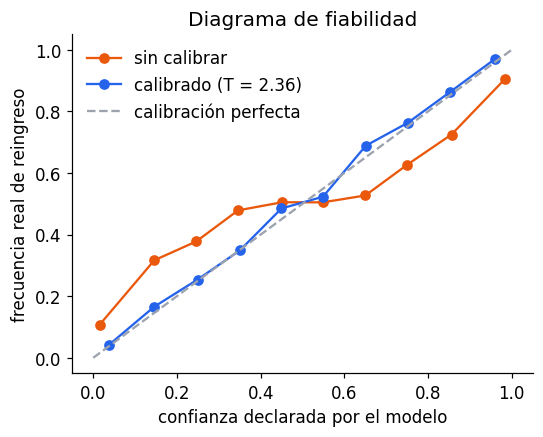

In [2]:
#@title 1 · Calibración (ECE y diagrama de fiabilidad)
def ece(y, p, bins=10):
    b = np.minimum((p * bins).astype(int), bins - 1)
    return sum((b == k).mean() * abs(y[b == k].mean() - p[b == k].mean())
               for k in range(bins) if (b == k).any())

def nll(y, p):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

z_sobre = 2.5 * z                                   # modelo desplegado SOBRECONFIADO (simulado)
Ts = np.linspace(0.5, 5, 451)
T = Ts[np.argmin([nll(Y[ca], sigmoid(z_sobre[ca] / t)) for t in Ts])]   # T se ajusta en calibración
p_sobre, p_cal = sigmoid(z_sobre), sigmoid(z_sobre / T)
riesgo = lambda df: sigmoid(2.5 * modelo.decision_function(df) / T)      # riesgo ya calibrado

ece_antes, ece_despues = ece(Y[te], p_sobre[te]), ece(Y[te], p_cal[te])
print(f"ECE sin calibrar = {ece_antes:.3f}  →  ECE calibrado = {ece_despues:.3f}   (T estimado = {T:.2f})")

fig, ax = plt.subplots(figsize=(5.4, 4))
for p, nombre, color in ((p_sobre, "sin calibrar", NARANJA), (p_cal, f"calibrado (T = {T:.2f})", AZUL)):
    b = np.minimum((p[te] * 10).astype(int), 9)
    ok = [k for k in range(10) if (b == k).sum() >= 20]
    ax.plot([p[te][b == k].mean() for k in ok], [Y[te][b == k].mean() for k in ok],
            "o-", color=color, label=nombre)
ax.plot([0, 1], [0, 1], "--", color=GRIS, label="calibración perfecta")
ax.set(xlabel="confianza declarada por el modelo", ylabel="frecuencia real de reingreso",
       title="Diagrama de fiabilidad")
ax.legend(frameon=False)
plt.show()
PANEL["Generativa"] = ("ECE: sin calibrar → calibrado", f"{ece_antes:.3f} → {ece_despues:.3f}")

**Mensaje clave.** La curva naranja se aleja de la diagonal: cuando el modelo dice «90 %», acierta bastante menos. Tras dividir los *logits* por $T$, la confianza vuelve a significar probabilidad. **Sin este paso, el umbral de supervisión del acto 3 no tendría sentido.**

## Acto 2 · ¿Está respaldada por evidencia?

**Qué hace.** El «LLM» produce 10 afirmaciones clínicas: 5 verdaderas y 5 **falsas pero plausibles** (mismo tema, dato cambiado). Cada afirmación $a$ se compara con una pequeña base de evidencia curada, se busca el documento más parecido $d^{*}$ y se aplica la regla de la ecuación (2) del paper:

$$\text{entregar}(a)\iff\text{similitud}(a,d^{*})\ge\tau_s\;\wedge\;\text{verificador}(d^{*},a)$$

Es decir, la afirmación se entrega solo si habla del mismo tema que la evidencia (similitud mayor que el umbral $\tau_s$) **y** dice lo mismo (el verificador la acepta); si no, se escala a una persona. La similitud se calcula con TF-IDF de fragmentos de caracteres (en producción sería un *embedding*). El verificador es didáctico: revisa que la afirmación no traiga cifras que no estén en la evidencia ni invierta una negación, y ocupa el lugar del modelo de implicación lógica (NLI) del paper. La evidencia $d^{*}$ que se cita es la **explicación** que vería el clínico.

**Por qué.** Es el caso típico de *bullshit* clínico: una frase que «suena» igual a la evidencia pero dice otra cosa.

**En el paper.** Sección 2.2, ecuación (2), y el *trade-off* «más modelos no producen más verdad» de la sección 3.

,afirmación del LLM,¿verdadera?,similitud,solo similitud,ec. (2): similitud + verificador,evidencia citada d*
0,la dosis de amoxicilina en ninos es 25 mg por kg cada 12 horas,✅,0.82,entrega,entrega,la dosis pediatrica de amoxicilina es de 25 mg por kg cada 12 horas
1,la metformina es de primera linea en diabetes tipo 2 sin complicaciones,✅,0.89,entrega,entrega,la metformina es el farmaco de primera linea para diabetes tipo 2 sin complicaciones
2,el objetivo de presion arterial es menor a 130 sobre 80 mmhg,✅,0.85,entrega,entrega,la presion arterial objetivo en la mayoria de adultos es menor a 130 sobre 80 mmhg
3,la aspirina a dosis baja previene eventos cardiovasculares secundarios,✅,0.99,entrega,entrega,la aspirina en dosis baja previene eventos cardiovasculares secundarios
4,la amoxicilina no debe usarse en alergia a la penicilina,✅,0.68,entrega,entrega,la amoxicilina esta contraindicada en pacientes con alergia a la penicilina
5,la dosis de amoxicilina en ninos es 250 mg por kg cada 12 horas,❌,0.80,entrega,escala,la dosis pediatrica de amoxicilina es de 25 mg por kg cada 12 horas
6,la metformina es de segunda linea en diabetes tipo 2 sin complicaciones,❌,0.79,entrega,entrega,la metformina es el farmaco de primera linea para diabetes tipo 2 sin complicaciones
7,el objetivo de presion arterial es menor a 180 sobre 110 mmhg,❌,0.82,entrega,escala,la presion arterial objetivo en la mayoria de adultos es menor a 130 sobre 80 mmhg
8,la aspirina a dosis baja se recomienda como prevencion primaria en mayores de 60 anos,❌,0.92,entrega,escala,la aspirina no se recomienda como prevencion primaria en mayores de 60 anos
9,la amoxicilina se recomienda en pacientes con alergia a la penicilina,❌,0.76,entrega,escala,la amoxicilina esta contraindicada en pacientes con alergia a la penicilina


Afirmaciones FALSAS que llegarían al paciente → solo similitud: 5/5 | similitud + verificador: 1/5


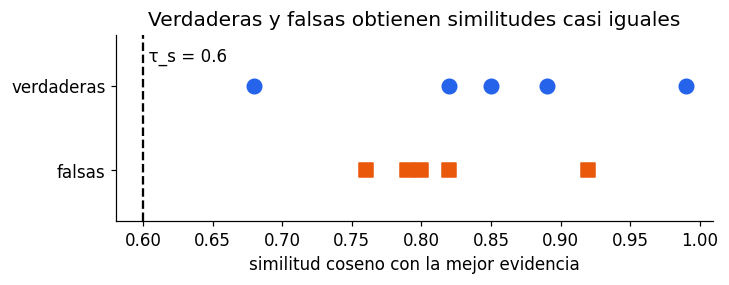

In [3]:
#@title 2 · Verificación contra evidencia curada
evidencia = [
    "la dosis pediatrica de amoxicilina es de 25 mg por kg cada 12 horas",
    "la amoxicilina esta contraindicada en pacientes con alergia a la penicilina",
    "la metformina es el farmaco de primera linea para diabetes tipo 2 sin complicaciones",
    "la metformina debe suspenderse 48 horas antes de un estudio con contraste yodado",
    "la aspirina en dosis baja previene eventos cardiovasculares secundarios",
    "la aspirina no se recomienda como prevencion primaria en mayores de 60 anos",
    "la presion arterial objetivo en la mayoria de adultos es menor a 130 sobre 80 mmhg",
    "la hemoglobina glicosilada se mide cada 3 meses en diabetes descompensada",
]
afirmaciones = [   # (texto generado por el "LLM", ¿es verdadera?)
    ("la dosis de amoxicilina en ninos es 25 mg por kg cada 12 horas", True),
    ("la metformina es de primera linea en diabetes tipo 2 sin complicaciones", True),
    ("el objetivo de presion arterial es menor a 130 sobre 80 mmhg", True),
    ("la aspirina a dosis baja previene eventos cardiovasculares secundarios", True),
    ("la amoxicilina no debe usarse en alergia a la penicilina", True),
    ("la dosis de amoxicilina en ninos es 250 mg por kg cada 12 horas", False),
    ("la metformina es de segunda linea en diabetes tipo 2 sin complicaciones", False),
    ("el objetivo de presion arterial es menor a 180 sobre 110 mmhg", False),
    ("la aspirina a dosis baja se recomienda como prevencion primaria en mayores de 60 anos", False),
    ("la amoxicilina se recomienda en pacientes con alergia a la penicilina", False),
]
TAU_S = 0.6  #@param {type:"slider", min:0.3, max:0.95, step:0.05}

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)).fit(evidencia)
E = vec.transform(evidencia)
NEGACION = {"no", "contraindicada", "nunca"}

def verificador(d, a):
    # Sustituto didáctico de un modelo NLI: la afirmación no puede traer cifras
    # que no estén en la evidencia ni invertir su polaridad (negación).
    cifras = lambda s: set(re.findall(r"\d+", s))
    negada = lambda s: bool(NEGACION & set(s.split()))
    return cifras(a) <= cifras(d) and negada(a) == negada(d)

filas = []
for a, verdadera in afirmaciones:
    sims = cosine_similarity(vec.transform([a]), E)[0]
    d = evidencia[sims.argmax()]
    pasa_sim = sims.max() >= TAU_S
    pasa_ec2 = pasa_sim and verificador(d, a)
    filas.append({"afirmación del LLM": a,
                  "¿verdadera?": "✅" if verdadera else "❌",
                  "similitud": round(float(sims.max()), 2),
                  "solo similitud": "entrega" if pasa_sim else "escala",
                  "ec. (2): similitud + verificador": "entrega" if pasa_ec2 else "escala",
                  "evidencia citada d*": d})
tabla = pd.DataFrame(filas)
display(tabla)

falsas = tabla["¿verdadera?"] == "❌"
fuga_sim = int(((tabla["solo similitud"] == "entrega") & falsas).sum())
fuga_ec2 = int(((tabla["ec. (2): similitud + verificador"] == "entrega") & falsas).sum())
print(f"Afirmaciones FALSAS que llegarían al paciente → solo similitud: {fuga_sim}/5 | "
      f"similitud + verificador: {fuga_ec2}/5")

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.scatter(tabla.similitud[~falsas], np.ones((~falsas).sum()), s=90, color=AZUL, label="verdaderas")
ax.scatter(tabla.similitud[falsas], np.zeros(falsas.sum()), s=90, marker="s", color=NARANJA, label="falsas")
ax.axvline(TAU_S, ls="--", color="k")
ax.text(TAU_S, 1.45, f" τ_s = {TAU_S}", va="top")
ax.set(yticks=[0, 1], yticklabels=["falsas", "verdaderas"], ylim=(-0.6, 1.6),
       xlabel="similitud coseno con la mejor evidencia",
       title="Verdaderas y falsas obtienen similitudes casi iguales")
plt.show()
PANEL["Verificación"] = ("Falsas que pasan: solo similitud → con verificador", f"{fuga_sim}/5 → {fuga_ec2}/5")

**Mensaje clave.** Para la similitud, «25 mg» y «250 mg» son casi la misma frase: cualquier umbral deja pasar errores o escala respuestas correctas. El verificador atrapa cifras y negaciones, pero **«segunda línea» se le escapa**. La verificación automática es necesaria pero no suficiente; lo que se escapa es trabajo de la capa humana (acto 3).

## Acto 2b · ¿Por qué el modelo de riesgo marcó a este paciente?

**Qué hace.** Explica la predicción de riesgo de un paciente ficticio con **valores de Shapley exactos**. La contribución de cada variable es su efecto marginal promedio sobre la predicción, considerando todos los órdenes en que las variables podrían incorporarse (con 5 variables son $2^5=32$ combinaciones, así que se calculan sin aproximar). Luego comprueba la propiedad de **eficiencia**: las contribuciones deben sumar exactamente la diferencia entre el riesgo del paciente y el riesgo promedio de la población.

**Por qué.** Muestra qué puede y qué no puede hacer la explicabilidad: es exacta y auditable, pero describe al modelo, no a la medicina.

**En el paper.** Sección 2.2 (explicabilidad) y el *trade-off* «explicar no es justificar» de la sección 3.

Riesgo del paciente = 64%  (referencia poblacional = 43%)
Propiedad de eficiencia: Σφ = +0.2092 | f(F) − f(∅) = +0.2092 | error = 2.8e-17


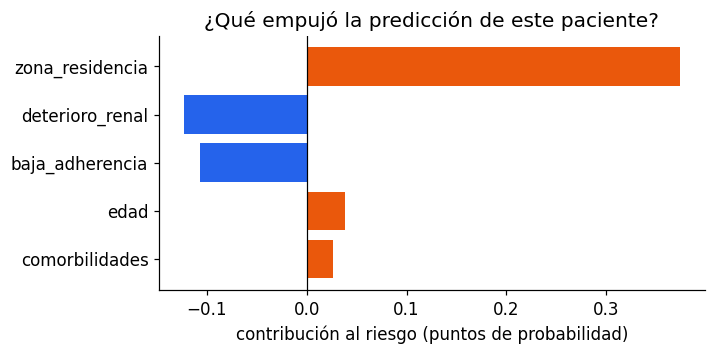

In [4]:
#@title 2b · Explicación con valores de Shapley exactos
rasgos = list(X.columns)
referencia = X.iloc[tr].mean().values
paciente = np.array([0.1, 0.1, 0, 0, 2.2])     # perfil clínico promedio, vive en una zona "alta"

def f(S):
    # Riesgo calibrado usando los valores del paciente en S y la referencia en el resto.
    x = referencia.copy()
    x[list(S)] = paciente[list(S)]
    return float(riesgo(pd.DataFrame([x], columns=rasgos))[0])

M = len(rasgos)
phi = np.zeros(M)
for i in range(M):
    otros = [j for j in range(M) if j != i]
    for k in range(M):
        for S in combinations(otros, k):
            phi[i] += factorial(k) * factorial(M - k - 1) / factorial(M) * (f(set(S) | {i}) - f(set(S)))

error_ef = abs(phi.sum() - (f(range(M)) - f([])))
print(f"Riesgo del paciente = {f(range(M)):.0%}  (referencia poblacional = {f([]):.0%})")
print(f"Propiedad de eficiencia: Σφ = {phi.sum():+.4f} | f(F) − f(∅) = {f(range(M)) - f([]):+.4f} "
      f"| error = {error_ef:.1e}")

orden = np.argsort(np.abs(phi))
fig, ax = plt.subplots(figsize=(6.4, 3))
ax.barh(np.array(rasgos)[orden], phi[orden], color=[NARANJA if v > 0 else AZUL for v in phi[orden]])
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="contribución al riesgo (puntos de probabilidad)",
       title="¿Qué empujó la predicción de este paciente?")
plt.show()
PANEL["Explicabilidad"] = ("Error de eficiencia de Shapley |Σφ − (f(F) − f(∅))|", f"{error_ef:.1e}")

**Mensaje clave.** La atribución es exacta y verificable (la eficiencia se cumple a precisión de máquina), pero explica **qué patrones usó el modelo, no si es clínicamente correcto**. Y revela algo incómodo: `zona_residencia`, que no es una variable clínica, pesa en la predicción porque es un *proxy* del grupo $A$. Eso se audita en el acto 4.

## Acto 3 · ¿Cuándo debe decidir una persona?

**Qué hace.** Aplica la regla de supervisión de la ecuación (3) del paper: se escala a un profesional toda decisión cuya confianza calibrada $\pi$ quede por debajo de

$$1-\frac{c_h}{\rho\,c_e}$$

donde $c_h$ es el costo de una revisión, $c_e$ el costo de un error que llega al paciente (aquí $c_e=1$) y $\rho$ la fracción de errores que el revisor detecta. Después busca por fuerza bruta el umbral que minimiza el costo real en los datos y lo compara con la fórmula. Por último, mide cuántos errores llegan al paciente cuando el revisor se vuelve menos atento.

**Por qué.** Prueba que la supervisión humana se puede tratar como una política de decisión derivada de costos, y no como un simple aviso de «verifique la información». También muestra el efecto del sesgo de automatización: si el revisor aprueba casi todo ($\rho$ bajo), la supervisión deja de proteger.

**En el paper.** Sección 2.3, ecuación (3), y el *trade-off* «el humano en el circuito no es automáticamente complementario» de la sección 3.

**Pruébalo:** mueve los deslizadores `c_h` (costo de revisar, en proporción al costo de un error) y `rho`.

Umbral óptimo empírico t* = 0.77  |  teoría, ec. (3): 1 − c_h/(ρ·c_e) = 0.75
Costo por caso en el óptimo empírico = 0.1405 | en el umbral teórico = 0.1418
Se escala al humano el 35% de los casos | errores que llegan al paciente: 18.1% sin supervisión → 5.3% con supervisión


,ρ (errores que detecta el revisor),% escalado,error que llega al paciente,costo esperado
0,1.000,0.319,0.062,0.142
1,0.800,0.319,0.086,0.166
2,0.500,0.319,0.121,0.201
3,0.200,0.319,0.157,0.237


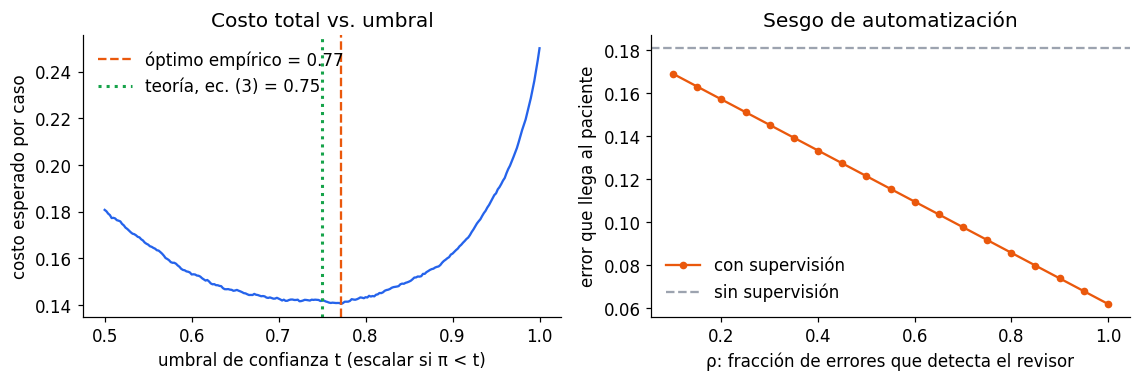

In [5]:
#@title 3 · Umbral de escalado y sesgo de automatización
c_h = 0.25  #@param {type:"slider", min:0.05, max:0.9, step:0.05}
rho = 1.0   #@param {type:"slider", min:0.1, max:1.0, step:0.05}
c_e = 1.0

p, y = p_cal[te], Y[te]
error = (p >= 0.5).astype(int) != y          # el modelo se equivoca
pi = np.maximum(p, 1 - p)                    # probabilidad calibrada de acertar

def evaluar(t, rho):
    # Valores esperados: el revisor detecta (y corrige) una fracción rho de los errores escalados.
    escala = pi < t
    llega = (error & ~escala).mean() + (1 - rho) * (error & escala).mean()
    return {"escalado": escala.mean(), "error_final": llega, "costo": c_h * escala.mean() + c_e * llega}

ts = np.linspace(0.5, 1.0, 251)
curva = pd.DataFrame([evaluar(t, rho) | {"t": t} for t in ts])
t_emp = curva.t[curva.costo.idxmin()]
t_teo = 1 - c_h / (rho * c_e)
mejor = curva.loc[curva.costo.idxmin()]
costo_teo = evaluar(max(t_teo, 0.5), rho)["costo"]
print(f"Umbral óptimo empírico t* = {t_emp:.2f}  |  teoría, ec. (3): 1 − c_h/(ρ·c_e) = {t_teo:.2f}")
print(f"Costo por caso en el óptimo empírico = {mejor.costo:.4f} | en el umbral teórico = {costo_teo:.4f}")
if t_teo <= 0.5:
    print("→ Con este ρ, revisar nunca compensa: la supervisión sería puramente nominal.")
print(f"Se escala al humano el {mejor.escalado:.0%} de los casos | errores que llegan al paciente: "
      f"{error.mean():.1%} sin supervisión → {mejor.error_final:.1%} con supervisión")

# efecto del sesgo de automatización: misma política (umbral óptimo con ρ = 1), revisor menos atento
t_fijo = 1 - c_h / c_e
filas = [{"ρ (errores que detecta el revisor)": r} | evaluar(t_fijo, r) for r in (1.0, 0.8, 0.5, 0.2)]
display(pd.DataFrame(filas).rename(columns={"escalado": "% escalado", "error_final": "error que llega al paciente",
                                            "costo": "costo esperado"}).map(lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
ax[0].plot(curva.t, curva.costo, color=AZUL)
ax[0].axvline(t_emp, color=NARANJA, ls="--", label=f"óptimo empírico = {t_emp:.2f}")
ax[0].axvline(max(t_teo, 0.5), color=VERDE, ls=":", lw=2, label=f"teoría, ec. (3) = {t_teo:.2f}")
ax[0].set(xlabel="umbral de confianza t (escalar si π < t)", ylabel="costo esperado por caso",
          title="Costo total vs. umbral")
ax[0].legend(frameon=False)
rhos = np.linspace(0.1, 1, 19)
ax[1].plot(rhos, [evaluar(t_fijo, r)["error_final"] for r in rhos], "o-", color=NARANJA, ms=4,
           label="con supervisión")
ax[1].axhline(error.mean(), color=GRIS, ls="--", label="sin supervisión")
ax[1].set(xlabel="ρ: fracción de errores que detecta el revisor", ylabel="error que llega al paciente",
          title="Sesgo de automatización")
ax[1].legend(frameon=False)
plt.tight_layout()
plt.show()
PANEL["Supervisión"] = ("t* empírico vs. ec. (3); % escalado; error sin → con supervisión",
                        f"{t_emp:.2f} vs {t_teo:.2f}; {mejor.escalado:.0%}; {error.mean():.1%} → {mejor.error_final:.1%}")

**Mensaje clave.** El umbral óptimo que se encuentra por fuerza bruta coincide con la fórmula $1-c_h/(\rho c_e)$ (la pequeña diferencia es ruido de muestreo: el costo en ambos puntos es prácticamente igual): la supervisión es una **política de decisión derivable de costos**, no un descargo de responsabilidad. Y su valor depende de $\rho$: si el revisor solo firma (ρ → 0), el error vuelve al nivel sin supervisión, como en el estudio de mamografía citado en el paper (Dratsch et al., 2023).

## Acto 4 · ¿Es justo con ambos grupos?

**Qué hace.** Audita el modelo de riesgo por grupos. El modelo **nunca vio** el atributo sensible $A$, pero usa `zona_residencia`, que está correlacionada con él. Mide tres brechas entre los grupos:

- **Paridad demográfica:** diferencia en la proporción de pacientes marcados como de alto riesgo.
- **$\Delta_{\mathrm{EO}}$ (ecuación 4 del paper):** la mayor diferencia entre grupos en la tasa de verdaderos positivos (¿detecta por igual a quienes sí reingresan?) o en la de falsos positivos (¿alarma por igual a quienes no?).
- **$\Delta_{\mathrm{PPV}}$:** diferencia en la proporción de alarmas que resultan correctas, ligada a la calibración por grupo.

Después aplica el posprocesamiento de Hardt et al. (2016): un umbral de decisión distinto por grupo, elegido para maximizar la exactitud con $\Delta_{\mathrm{EO}}\le\varepsilon$.

**Por qué.** Muestra que quitar la variable sensible no elimina el sesgo y que corregir una métrica de equidad mueve otra.

**En el paper.** Sección 2.3, ecuación (4), y el *trade-off* «la equidad no es un escalar» de la sección 3.

Tasa real de reingreso → grupo 0: 39% | grupo 1: 55% (tasas base distintas)
Umbral único 0.50  →  umbrales por grupo: t0 = 0.51, t1 = 0.55


,umbral único,umbral por grupo
Δ_DP (paridad demográfica),0.130,0.102
Δ_EO (equalized odds),0.058,0.030
Δ_PPV (≈ calibración por grupo),0.093,0.108
exactitud,0.819,0.818


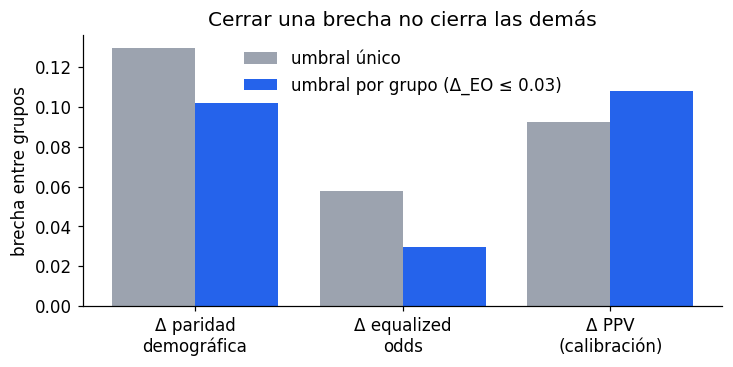

In [6]:
#@title 4 · Auditoría y mitigación de sesgos
EPS = 0.03  #@param {type:"slider", min:0.01, max:0.1, step:0.01}
p, y, a = p_cal[te], Y[te], A[te]

def metricas(pred):
    r = {}
    for g in (0, 1):
        m = a == g
        r[g] = (pred[m].mean(), pred[m & (y == 1)].mean(), pred[m & (y == 0)].mean(), y[m & (pred == 1)].mean())
    return {"Δ_DP (paridad demográfica)": abs(r[0][0] - r[1][0]),
            "Δ_EO (equalized odds)": max(abs(r[0][1] - r[1][1]), abs(r[0][2] - r[1][2])),
            "Δ_PPV (≈ calibración por grupo)": abs(r[0][3] - r[1][3]),
            "exactitud": (pred == y).mean()}

antes = metricas((p >= 0.5).astype(int))
grid = np.round(np.linspace(0.25, 0.75, 51), 3)
candidatos = []
for t0 in grid:
    for t1 in grid:
        m = metricas(np.where(a == 1, p >= t1, p >= t0).astype(int))
        candidatos.append((m["Δ_EO (equalized odds)"] > EPS, -m["exactitud"], t0, t1, m))
_, _, t0, t1, despues = min(candidatos, key=lambda c: c[:2])

print(f"Tasa real de reingreso → grupo 0: {y[a == 0].mean():.0%} | grupo 1: {y[a == 1].mean():.0%} "
      "(tasas base distintas)")
print(f"Umbral único 0.50  →  umbrales por grupo: t0 = {t0:.2f}, t1 = {t1:.2f}")
display(pd.DataFrame({"umbral único": antes, "umbral por grupo": despues}).map(lambda v: f"{v:.3f}"))

claves = list(antes)[:3]
xs = np.arange(len(claves))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar(xs - 0.2, [antes[k] for k in claves], 0.4, color=GRIS, label="umbral único")
ax.bar(xs + 0.2, [despues[k] for k in claves], 0.4, color=AZUL, label=f"umbral por grupo (Δ_EO ≤ {EPS})")
ax.set_xticks(xs, ["Δ paridad\ndemográfica", "Δ equalized\nodds", "Δ PPV\n(calibración)"])
ax.set(ylabel="brecha entre grupos", title="Cerrar una brecha no cierra las demás")
ax.legend(frameon=False)
plt.show()
PANEL["Equidad"] = ("Δ_EO y Δ_PPV: umbral único → por grupo; exactitud",
                    f"Δ_EO {antes['Δ_EO (equalized odds)']:.3f} → {despues['Δ_EO (equalized odds)']:.3f}; "
                    f"Δ_PPV {antes['Δ_PPV (≈ calibración por grupo)']:.3f} → {despues['Δ_PPV (≈ calibración por grupo)']:.3f}; "
                    f"exactitud {antes['exactitud']:.3f} → {despues['exactitud']:.3f}")

**Mensaje clave.** Quitar la variable sensible **no basta**: el *proxy* reintroduce la brecha (como en Obermeyer et al., 2019). Los umbrales por grupo reducen $\Delta_{\mathrm{EO}}$ a la mitad, pero la brecha de valor predictivo positivo (PPV, ligada a la calibración por grupo) **crece**. Con tasas base distintas no se pueden igualar todas a la vez (Kleinberg et al., 2017; Chouldechova, 2017): **elegir la métrica es una decisión de valor que debe declararse**.

## 5 · Panel de control *(Tabla 1 del paper con los valores de esta demo)*

In [7]:
#@title 5 · Panel de control
display(pd.DataFrame([(capa, *v) for capa, v in PANEL.items()],
                     columns=["Capa", "Métrica", "Valor en esta demo"]))

,Capa,Métrica,Valor en esta demo
0,Generativa,ECE: sin calibrar → calibrado,0.096 → 0.013
1,Verificación,Falsas que pasan: solo similitud → con verificador,5/5 → 1/5
2,Explicabilidad,Error de eficiencia de Shapley |Σφ − (f(F) − f(∅))|,2.8e-17
3,Supervisión,t* empírico vs. ec. (3); % escalado; error sin → con supervisión,0.77 vs 0.75; 35%; 18.1% → 5.3%
4,Equidad,Δ_EO y Δ_PPV: umbral único → por grupo; exactitud,Δ_EO 0.058 → 0.030; Δ_PPV 0.093 → 0.108; exactitud 0.819 → 0.818


## Conclusiones de la demo

1. **Calibrar es requisito para supervisar**: sin calibración, la confianza no sirve como $\pi$ en la ecuación (3).
2. **La evidencia ayuda, pero no basta**: la similitud no ve «250 mg»; un verificador atrapa más, pero no todo.
3. **La explicación es auditable, no una justificación clínica**; bien usada, delata *proxies*.
4. **La supervisión humana es una política con umbral derivable** y solo funciona si el revisor realmente anula ($\rho$ alto).
5. **La equidad es un *trade-off***: cerrar una brecha mueve otra.

**Limitaciones.** Datos sintéticos; corpus de juguete; TF-IDF en lugar de *embeddings*; verificador de reglas en lugar de un modelo NLI; regresión logística en lugar de un LLM. La demo reproduce el **mecanismo** y la **medición**, no el desempeño clínico.

**Transparencia IA.** Notebook generado con asistencia de IA (DeepSeek V4.1 Flash vía OpenCode en la primera versión; Claude Code, modelo Claude Opus 5.5, en la reescritura para presentación). Verificaciones incluidas en el propio código: eficiencia de Shapley (acto 2b) y coincidencia entre el umbral óptimo empírico y la ecuación (3) (acto 3).